
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models 
- Compare architectures


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from datasets import load_dataset
import pandas as pd

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
label_map = {
    "Human": 0,
    "Anthropic": 1,
    "Google": 2,
    "OpenAI": 3,
    "Meta": 4
}

In [3]:
from datasets import DatasetDict

# data loading
dataset = load_dataset("csv", data_files="../dataset_final.csv", sep=";")

ds_split = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_ds = ds_split["train"]
temp_ds = ds_split["test"]

sub_split = temp_ds.train_test_split(test_size=0.5, seed=42)
val_ds = sub_split["train"]
test_ds = sub_split["test"]

dataset = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds
})

print(dataset)

train_data = list(dataset["train"])
val_data = list(dataset["validation"])
test_data = list(dataset["test"])

# remove exemples without labels
train_data = [x for x in train_data if x["Label"] is not None]
val_data = [x for x in val_data if x["Label"] is not None]
test_data = [x for x in test_data if x["Label"] is not None]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

DatasetDict({
    train: Dataset({
        features: ['ID', 'Text', 'Label'],
        num_rows: 5596
    })
    validation: Dataset({
        features: ['ID', 'Text', 'Label'],
        num_rows: 700
    })
    test: Dataset({
        features: ['ID', 'Text', 'Label'],
        num_rows: 700
    })
})
Train size: 5596
Validation size: 700
Test size: 700


In [4]:
print(dataset["train"].features)
print(train_data[0])

{'ID': Value('large_string'), 'Text': Value('large_string'), 'Label': Value('large_string')}
{'ID': 'D1-2072', 'Text': 'Centrioles are cylindrical, paired structures composed of micro-tubules arranged in a specific nine-triplet pattern, typically found within the centrosome of animal cells. They play a critical role in organizing the microtubule cytoskeleton and are essential for the formation of the mitotic spindle during cellular division. Before a cell divides, the centrioles replicate, and each pair moves to opposite poles of the cell to anchor the spindle fibers that pull chromosomes apart. Additionally, centrioles serve as the basal bodies for the assembly of cilia and flagella, which are hair-like projections used for cellular locomotion or the movement of fluids across the cell surface', 'Label': 'Google'}


In [5]:
sum(1 for x in train_data if x["Label"] is None)

0

In [6]:
train_texts = [x["Text"] for x in train_data]
validation_texts = [x["Text"] for x in val_data]
test_texts = [x["Text"] for x in test_data]

train_labels = [label_map[x["Label"].strip()] for x in train_data]
validation_labels = [label_map[x["Label"].strip()] for x in val_data]
test_labels = [label_map[x["Label"].strip()] for x in test_data]


# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [7]:
import re

def tokenize(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

In [8]:
tokenize(train_data)

['id',
 'd',
 'text',
 'centrioles',
 'are',
 'cylindrical',
 'paired',
 'structures',
 'composed',
 'of',
 'micro',
 'tubules',
 'arranged',
 'in',
 'a',
 'specific',
 'nine',
 'triplet',
 'pattern',
 'typically',
 'found',
 'within',
 'the',
 'centrosome',
 'of',
 'animal',
 'cells',
 'they',
 'play',
 'a',
 'critical',
 'role',
 'in',
 'organizing',
 'the',
 'microtubule',
 'cytoskeleton',
 'and',
 'are',
 'essential',
 'for',
 'the',
 'formation',
 'of',
 'the',
 'mitotic',
 'spindle',
 'during',
 'cellular',
 'division',
 'before',
 'a',
 'cell',
 'divides',
 'the',
 'centrioles',
 'replicate',
 'and',
 'each',
 'pair',
 'moves',
 'to',
 'opposite',
 'poles',
 'of',
 'the',
 'cell',
 'to',
 'anchor',
 'the',
 'spindle',
 'fibers',
 'that',
 'pull',
 'chromosomes',
 'apart',
 'additionally',
 'centrioles',
 'serve',
 'as',
 'the',
 'basal',
 'bodies',
 'for',
 'the',
 'assembly',
 'of',
 'cilia',
 'and',
 'flagella',
 'which',
 'are',
 'hair',
 'like',
 'projections',
 'used',
 'fo

In [9]:
from collections import Counter

def build_vocab(texts, max_words=10000):

    counter = Counter()

    for text in texts:

        if text is None:
            continue

        tokens = tokenize(text)
        counter.update(tokens)

    most_common = counter.most_common(max_words)

    vocab = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word, _ in most_common:
        vocab[word] = len(vocab)

    return vocab

In [10]:
vocab = build_vocab(train_texts)


# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [11]:
def encode(vocab, text, max_len=25):
    tokens = tokenize(text)

    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

In [12]:
def one_hot_encode(vocab, token):
    vector = np.zeros(len(vocab))
    
    token_index = vocab.get(token, vocab["<unk>"])
    vector[token_index] = 1
    
    return vector

In [13]:
train_loader = DataLoader(
    dataset["train"],
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    dataset["validation"],
    batch_size = 32,
    shuffle = True

)

test_loader = DataLoader(
    dataset["test"],
    batch_size=32,
    shuffle=False
)


# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
  - Transformers
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [14]:
class Model(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 4)

        def forward(self, x):
            x = self.embedding(x)
            x = self.drpout(x)
            out, h = self.rnn(x)
            if isinstance(h, tuple):
                h = h[0]
                return self.fc(h[-1])


# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [15]:
def train(model, train_loader, val_loader, criterion, epochs = 10, lr = 0.001, verbose = True):
    ## verbose - print losses and accuracies per epoch
    
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs): 
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        train_accs.append(train_acc)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        val_losses.append(val_loss)

        if verbose: 
            print(f"Epoch {epoch+1}")
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    
    return train_accs, val_accs, train_losses, val_losses


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU
- Transformers

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


In [16]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

In [17]:
def plot_values(list_values, list_labels  = ["Train", "Validation"], ylabel = "Accuracy", title = None):
    plt.figure()
    for i in range(len(list_values)):
        plt.plot(list_values[i], label = list_labels[i])
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    if title is not None: plt.title()
    plt.show()

In [18]:
def load_dataset_embed(train_val_path, test_path, max_words, max_len=100, batch_size=32):
    print("A carregar datasets e a aplicar GroupShuffleSplit...")
    
    # ==========================================
    # 1. PREPARAR TREINO E VALIDAÇÃO (Dataset Mãe)
    # ==========================================
    df_main = pd.read_csv(train_val_path, sep=";")
    df_main = df_main.dropna(subset=['Text', 'Label', 'Original_ID']).reset_index(drop=True)

    # SPLIT NINJA: 80% Treino | 20% Validação (Agrupado pelo Original_ID)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(gss.split(df_main['Text'], df_main['Label'], groups=df_main['Original_ID']))

    df_train = df_main.iloc[train_idx].reset_index(drop=True)
    df_val = df_main.iloc[val_idx].reset_index(drop=True)

    # ==========================================
    # 2. PREPARAR TESTE (Dataset Antigo)
    # ==========================================
    df_test = pd.read_csv(test_path, sep=";")
    # Como é o dataset antigo, garantimos apenas que tem Text e Label
    df_test = df_test.dropna(subset=['Text', 'Label']).reset_index(drop=True)

    # ==========================================
    # 3. CONVERTER PARA DICIONÁRIOS E VOCABULÁRIO
    # ==========================================
    train_data = df_train.to_dict('records')
    val_data = df_val.to_dict('records')
    test_data = df_test.to_dict('records')

    # O Vocabulário continua a ser construído APENAS com os dados de treino!
    train_texts = [x["Text"] for x in train_data]
    vocab = build_vocab(train_texts, max_words)

    # ==========================================
    # 4. DATALOADERS
    # ==========================================
    def collate(batch):
        texts = [x["Text"] for x in batch]
        labels = [label_map[x["Label"].strip()] for x in batch]
    
        encoded = [encode(vocab, t, max_len) for t in texts]
    
        x = torch.tensor(encoded, dtype=torch.long)
        y = torch.tensor(labels, dtype=torch.long)
        return x.to(device), y.to(device)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, collate_fn=collate)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate)

    return train_loader, val_loader, test_loader, vocab

In [19]:
class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        last_hidden = hidden[-1]
        out = self.fc(last_hidden)
        return out

In [20]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)     # (B, L, E)
        output, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]

        last_hidden = self.dropout(last_hidden)

        out = self.fc(last_hidden)

        return out   # (B, num_classes)

In [21]:
class GRUClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.0, bidirectional=False, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        direction_factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * direction_factor, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)

        if self.gru.bidirectional:
            forward_hidden = hidden[-2]
            backward_hidden = hidden[-1]
            last_hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        else:
            last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)
        return out   # (B, num_classes)

## Transformer architecture

In [22]:
import math

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (same formula as the original
    "Attention Is All You Need" paper).

    Adds position information to the token embeddings so the model
    knows the order of words — Transformers have no built-in notion
    of sequence order unlike RNNs.
    """

    def __init__(self, embed_dim, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)

        for pos in range(max_len):
            for i in range(0, embed_dim, 2):
                pe[pos, i]     = math.sin(pos / (10000 ** (i / embed_dim)))
                pe[pos, i + 1] = math.cos(pos / (10000 ** (i / embed_dim)))

        # Shape: (1, max_len, embed_dim) — the leading 1 broadcasts over batches
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x: (batch, seq_len, embed_dim)
        return x + self.pe[:, :x.size(1)]


class SelfAttention(nn.Module):
    """
    Single-head scaled dot-product attention.

    Q, K, V are linear projections of the same input x (self-attention).
    Each token can directly attend to every other token in the sequence,
    which is the key advantage over RNNs where information must travel
    step-by-step.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.q(x)   # (B, L, D)
        K = self.k(x)   # (B, L, D)
        V = self.v(x)   # (B, L, D)

        # Scale to prevent vanishing gradients in softmax
        scale  = math.sqrt(Q.size(-1))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale   # (B, L, L)
        weights = torch.softmax(scores, dim=-1)

        return torch.matmul(weights, V)   # (B, L, D)


class MultiHeadAttention(nn.Module):
    """
    Multiple independent attention heads run in parallel.

    Each head learns to attend to different aspects of the text
    (e.g. one head might focus on syntactic structure, another on
    semantic similarity). Outputs are concatenated and projected back.
    """

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.heads  = nn.ModuleList(
            [SelfAttention(embed_dim) for _ in range(num_heads)]
        )
        # Project the concatenated head outputs back to embed_dim
        self.linear = nn.Linear(embed_dim * num_heads, embed_dim)

    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]   # num_heads × (B, L, D)
        concat = torch.cat(head_outputs, dim=-1)           # (B, L, D * num_heads)
        return self.linear(concat)                         # (B, L, D)


class TransformerBlock(nn.Module):
    """
    One encoder layer:
      1. Multi-head self-attention
      2. Residual connection + LayerNorm
      3. Position-wise feed-forward network
      4. Residual connection + LayerNorm

    Residual connections let gradients flow through deep stacks;
    LayerNorm stabilises training.
    """

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm2   = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention sub-layer
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward sub-layer
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x


# ─────────────────────────────────────────────
# Full classifier
# ─────────────────────────────────────────────

class TransformerClassifier(nn.Module):
    """
    Transformer encoder for text classification.

    Architecture:
      token ids
        → Embedding
        → + Positional Encoding
        → N × TransformerBlock
        → mean-pool over sequence
        → Linear classifier

    Mean-pooling is used instead of taking only the first/last token
    so that every position contributes equally to the final prediction.

    Args:
        vocab_size  : size of the vocabulary (including <pad> and <unk>)
        embed_dim   : token embedding dimension
        num_heads   : number of attention heads per block
        ff_dim      : inner dimension of the feed-forward sublayer
        num_layers  : number of stacked TransformerBlocks
        num_classes : number of output classes (5 for this project)
        max_len     : maximum sequence length (must match encode() max_len)
        dropout     : dropout probability applied inside each block
    """

    def __init__(
        self,
        vocab_size,
        embed_dim   = 128,
        num_heads   = 4,
        ff_dim      = 256,
        num_layers  = 2,
        num_classes = 5,
        max_len     = 120,
        dropout     = 0.3,
    ):
        super().__init__()

        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding  = PositionalEncoding(embed_dim, max_len)
        self.dropout       = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)

        out = self.embedding(x)        # (B, L, D)
        out = self.pos_encoding(out)   # (B, L, D)
        out = self.dropout(out)

        for layer in self.layers:
            out = layer(out)           # (B, L, D)

        # Mean-pool over the sequence dimension
        out = out.mean(dim=1)          # (B, D)

        return self.classifier(out)    # (B, num_classes)

In [23]:
def test_rnn():
    train_val_path = "../dataset_master_final.csv"
    test_path      = "../dataset_final_v3.csv"
    max_words = 20000
    max_len = 100
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(
        train_val_path, test_path, max_words, max_len=max_len
    )
    vocab_size_real = len(vocab_local)
    model = RNNClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=1)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 10)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    # ── Final test evaluation ─────────────────────────────────────────────
    print("\nA iniciar avaliação no Dataset de Teste (v3)...")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # E fazemos o plot da matriz de confusão também!
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_lstm():
    train_val_path = "../dataset_master_final.csv"
    test_path      = "../dataset_final_v3.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(
        train_val_path, test_path, max_words, max_len=max_len
    )
    vocab_size_real = len(vocab_local)
    model = LSTMClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=2, bidirectional = True, dropout = 0.5)
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 10) #, lr = 0.0001)

    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    # ── Final test evaluation ─────────────────────────────────────────────
    print("\nA iniciar avaliação no Dataset de Teste (v3)...")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # E fazemos o plot da matriz de confusão também!
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_gru():
    train_val_path = "../dataset_master_final.csv"
    test_path      = "../dataset_final_v3.csv"
    max_words = 20000
    max_len = 100 ## do not increase
    embed_dim = 200
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(
        train_val_path, test_path, max_words, max_len=max_len
    )
    vocab_size_real = len(vocab_local)
    model = GRUClassifier(vocab_size_real,embed_dim, hidden_dim=128, num_layers=1, bidirectional = True, dropout = 0.3)
    
    criterion = nn.CrossEntropyLoss()
    
    train_accs, val_accs, train_losses, val_losses = train(model, train_loader, val_loader, criterion, epochs = 5) #, lr = 0.0001)
    
    plot_values([train_accs, val_accs])
    plot_values([train_losses, val_losses], ylabel = "Loss")
    
    # ── Final test evaluation ─────────────────────────────────────────────
    print("\nA iniciar avaliação no Dataset de Teste (v3)...")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # E fazemos o plot da matriz de confusão também!
    confusion_matrix_eval(model, test_loader)
    return model, vocab_local

def test_transformer():
    train_val_path = "../dataset_master_final.csv"
    test_path      = "../dataset_final_v3.csv"
    max_words  = 20000
    max_len    = 100
    embed_dim  = 128
    num_heads  = 4
    ff_dim     = 256
    num_layers = 2
    dropout    = 0.4     
 
    train_loader, val_loader, test_loader, vocab_local = load_dataset_embed(
        train_val_path, test_path, max_words, max_len=max_len
    )
 
    vocab_size = len(vocab_local)
 
    model = TransformerClassifier(
        vocab_size  = vocab_size,
        embed_dim   = embed_dim,
        num_heads   = num_heads,
        ff_dim      = ff_dim,
        num_layers  = num_layers,
        num_classes = 5,
        max_len     = max_len,
        dropout     = dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
 
    # ── Early stopping config ─────────────────────────────────────────────
    num_epochs    = 20          # high ceiling — early stopping will cut it short
    patience      = 5           # stop if val_acc doesn't improve for 4 epochs
    best_val_acc  = 0.0
    no_improve    = 0
    best_path     = "best_transformer.pt"
    # ─────────────────────────────────────────────────────────────────────
 
    train_accs, val_accs, train_losses, val_losses = [], [], [], []
 
    for epoch in range(num_epochs):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
 
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
            running_loss += loss.item() * xb.size(0)
            correct      += (logits.argmax(1) == yb).sum().item()
            total        += yb.size(0)
 
        train_loss = running_loss / total
        train_acc  = correct / total
 
        # ── Validation ────────────────────────────────────────────────────
        val_loss, val_acc = evaluate(model, val_loader, criterion)
 
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
 
        print(f"Epoch {epoch+1:>2} | "
              f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}", end="")
 
        # ── Early stopping check ──────────────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            torch.save(model.state_dict(), best_path)
            print("  ← saved")
        else:
            no_improve += 1
            print(f"  (no improve {no_improve}/{patience})")
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}. "
                      f"Best val_acc={best_val_acc:.4f}")
                break
 
    # ── Restore best checkpoint ───────────────────────────────────────────
    model.load_state_dict(torch.load(best_path))
    print(f"\nRestored best checkpoint ({best_path}).")
 
    # ── Plots ─────────────────────────────────────────────────────────────
    plot_values([train_accs,   val_accs],   ylabel="Accuracy")
    plot_values([train_losses, val_losses], ylabel="Loss")
 
    # ── Final test evaluation ─────────────────────────────────────────────
    print("\nA iniciar avaliação no Dataset de Teste (v3)...")
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # E fazemos o plot da matriz de confusão também!
    confusion_matrix_eval(model, test_loader)
 
    return model, vocab_local


# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def confusion_matrix_eval(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:

            outputs = model(x)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()

A carregar datasets e a aplicar GroupShuffleSplit...
Epoch  1 | train_loss=0.6460  train_acc=0.7448 | val_loss=0.5342  val_acc=0.8203  ← saved
Epoch  2 | train_loss=0.4100  train_acc=0.8444 | val_loss=0.2766  val_acc=0.8987  ← saved
Epoch  3 | train_loss=0.3305  train_acc=0.8765 | val_loss=0.4281  val_acc=0.8570  (no improve 1/5)
Epoch  4 | train_loss=0.2938  train_acc=0.8888 | val_loss=0.2751  val_acc=0.9081  ← saved
Epoch  5 | train_loss=0.2620  train_acc=0.9024 | val_loss=0.2492  val_acc=0.9179  ← saved
Epoch  6 | train_loss=0.2417  train_acc=0.9115 | val_loss=0.2396  val_acc=0.9226  ← saved
Epoch  7 | train_loss=0.2213  train_acc=0.9156 | val_loss=0.3157  val_acc=0.9001  (no improve 1/5)
Epoch  8 | train_loss=0.2127  train_acc=0.9211 | val_loss=0.2268  val_acc=0.9269  ← saved
Epoch  9 | train_loss=0.2005  train_acc=0.9258 | val_loss=0.2372  val_acc=0.9246  (no improve 1/5)
Epoch 10 | train_loss=0.1858  train_acc=0.9321 | val_loss=0.2908  val_acc=0.9091  (no improve 2/5)
Epoch 11 | 

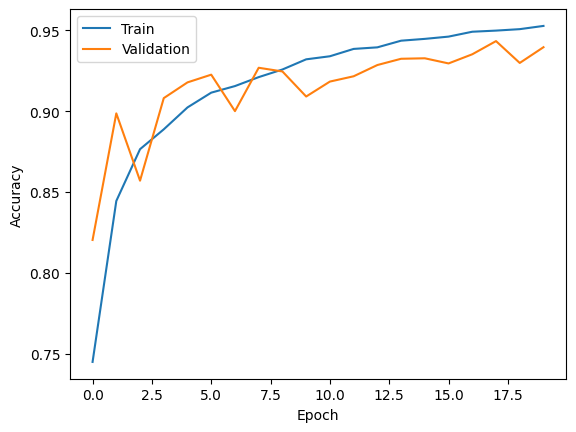

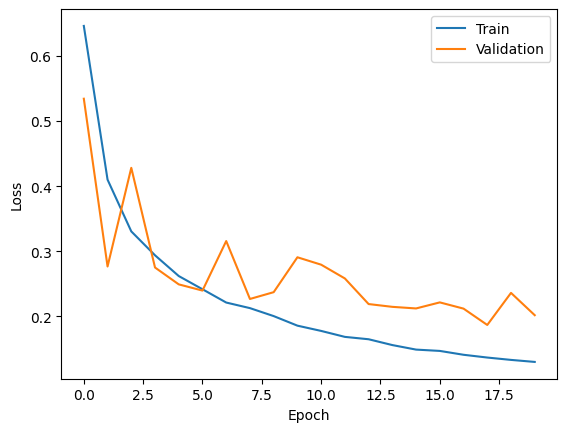


A iniciar avaliação no Dataset de Teste (v3)...
Test Accuracy: 0.2237


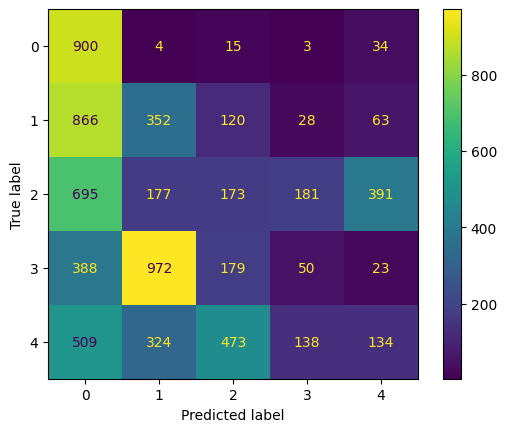

In [27]:
#model_rnn, vocab_do_treino = test_rnn() # val_acc = ~0.50
#model_lstm, vocab_do_treino = test_lstm() # val_acc = 0.71
# model_gru, vocab_do_treino = test_gru() # val_acc = 0.74
model_transformer, vocab_do_treino = test_transformer()

A prever 196 textos...

🎯 ACCURACY FINAL (Professor): 0.6020
✅ Textos corretos: 118 de 196

📊 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       Human       0.63      0.91      0.75        66
   Anthropic       0.50      0.47      0.48        32
      Google       0.69      0.51      0.59        35
      OpenAI       0.33      0.14      0.20        29
        Meta       0.64      0.62      0.63        34

    accuracy                           0.60       196
   macro avg       0.56      0.53      0.53       196
weighted avg       0.58      0.60      0.57       196



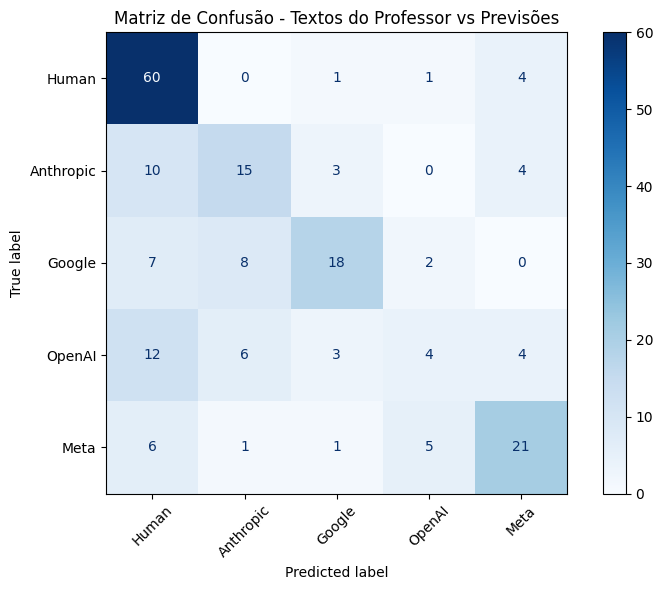

In [28]:
def avaliar_submissoes_professor(model, vocab, texts_file, labels_file, max_len=100):
    # 1. Carregar os ficheiros CSV (Atenção: usando sep=',' conforme o teu código anterior)
    try:
        df_texts = pd.read_csv(texts_file, sep=',')
        df_labels = pd.read_csv(labels_file, sep=',')
    except FileNotFoundError:
        print("❌ Erro: Não foi possível encontrar os ficheiros CSV. Verifica os caminhos!")
        return
    
    # Garantir que não há valores nulos
    df_texts = df_texts.dropna(subset=['Text']).reset_index(drop=True)
    df_labels = df_labels.dropna(subset=['Label']).reset_index(drop=True)
    
    # 2. Fazer as previsões
    model.eval()
    previsoes_numericas = []
    
    print(f"A prever {len(df_texts)} textos...")
    with torch.no_grad():
        for text in df_texts["Text"]:
            # Usar a função de encode que construíste com o vocabulário de treino
            seq = encode(vocab, str(text), max_len)
            x = torch.tensor(seq).unsqueeze(0).to(device)
            
            # Obter a previsão do modelo
            outputs = model(x)
            pred_idx = torch.argmax(outputs, dim=1).item()
            previsoes_numericas.append(pred_idx)
            
    # 3. Converter as labels reais (Strings) em números para podermos comparar
    # Usamos o teu label_map: {"Human": 0, "Anthropic": 1, "Google": 2, "OpenAI": 3, "Meta": 4}
    labels_reais_numericas = [label_map[label.strip()] for label in df_labels["Label"]]
    
    # 4. Calcular Métricas
    accuracy = accuracy_score(labels_reais_numericas, previsoes_numericas)
    certos = sum(1 for p, r in zip(previsoes_numericas, labels_reais_numericas) if p == r)
    total = len(labels_reais_numericas)
    
    print("\n==========================================")
    print(f"🎯 ACCURACY FINAL (Professor): {accuracy:.4f}")
    print(f"✅ Textos corretos: {certos} de {total}")
    print("==========================================\n")
    
    # Nomes das classes pela ordem do label_map para os gráficos ficarem bonitos
    nomes_classes = list(label_map.keys())
    
    print("📊 Relatório de Classificação Detalhado:")
    print(classification_report(labels_reais_numericas, previsoes_numericas, target_names=nomes_classes))
    
    # 5. Matriz de Confusão
    cm = confusion_matrix(labels_reais_numericas, previsoes_numericas)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title("Matriz de Confusão - Textos do Professor vs Previsões")
    plt.tight_layout()
    plt.show()

# ==========================================
# CÓDIGO DE EXECUÇÃO (Para correr a função)
# ==========================================
caminho_textos = '../everySubm_revealed_texts.csv'
caminho_labels = '../everySubm_revealed_labels.csv'

avaliar_submissoes_professor(model_transformer, vocab_do_treino, caminho_textos, caminho_labels, max_len=100)


# Part 7 - submission file


In [29]:
def fill_csv(model, input_file, output_file, vocab, max_len=100):
    dataset = load_dataset("csv", data_files=input_file, sep=";")["train"]

    inverse_label_map = {v: k for k, v in label_map.items()}

    model.eval()
    predictions = []

    with torch.no_grad():
        for text in dataset["Text"]:
            seq = encode(vocab, str(text), max_len)
            x   = torch.tensor(seq).unsqueeze(0).to(device)
            pred_idx   = torch.argmax(model(x), dim=1).item()
            predictions.append(inverse_label_map[pred_idx])

    # Write output: only ID and Label, ; separated, original order preserved
    with open(output_file, "w", encoding="utf-8") as f:
        f.write("ID;Label\n")
        for row_id, label in zip(dataset["ID"], predictions):
            f.write(f"{row_id};{label}\n")

    print(f"Saved {len(predictions)} predictions → {output_file}")

In [ ]:
fill_csv(model_transformer, "../subm3.csv", "../subm3-g6-MEI-B.csv", vocab_do_treino, max_len = 100)